# AAV5 -- `Protocol` (classe mecaniste) sur les 50k variants org2 ∩ org3

Question : la classe `ProtocolV3` (simulation mecaniste plasmide -> virus -> organoïde), avec les
poids de Potts deja extraits et les **parametres classiques du projet** (pas de sweep cette fois),
reproduit-elle des stats/distributions plausibles pour la **selectivite**, sur exactement les
variants qu'on a identifies comme les plus fiables aujourd'hui (intersection org2 ∩ org3,
`AAV5_organoides_sorted_sel_org2org3.csv`) ?

**Choix de ce run** (differents du pendant precedent, `AAV5_SEL_fitting_protocol.ipynb`, dans
`obsolete/`) :

- **Memes variants que le CSV** : on ne prend PAS un pool synthetique -- on sous-echantillonne
  50 000 lignes de `AAV5_organoides_sorted_sel_org2org3.csv` (146 589 lignes, deja filtre
  `compte_organoide_2_adn>0` ET `compte_organoide_3_adn>0`, 7m8 retire).
- **Librairie initiale (`lambda0`) calibree pour qu'APRES `dilution_factor` on retombe sur la
  moyenne des comptages organoïde 2 et 3**, PAS le `compte_plasmide` reel -- `plasmid_count(s) =
  avg(compte_organoide_2_adn(s), compte_organoide_3_adn(s))` est la cible du checkpoint dilue,
  pas la valeur brute de `lambda0` : `lambda0(s) = plasmid_count(s) * dilution_factor`, pour que
  `sample_sequences()` (Binomial(lambda0, p=1/dilution_factor), moyenne `lambda0/dilution_factor`)
  retombe en esperance exactement sur `plasmid_count(s)`. Deux problemes numeriques rencontres et
  corriges en route (sections 1 et 4) : un variant extreme qui concentre 13% de la masse fait
  exploser la memoire de `produce_capsids()` (winsorisation p99, independante du facteur d'echelle
  choisi ensuite) ; et un premier essai qui laissait `lambda0` a l'echelle brute des comptages NGS
  (~1e7 au total) faisait s'effondrer le checkpoint NGS plasmide simule sur une poignee de
  sequences (92/50 000) -- `dilution_factor=1e5` est calibre pour des bibliotheques bien plus
  grandes. Ce notebook calibre `lambda0` directement sur `dilution_factor` (au lieu d'un rescale
  vers une masse totale arbitraire) pour que le checkpoint retombe pile sur `avg(org2,org3)`.
- **Parametres "classiques"** : repris tels quels de `AAV5_SEL_fitting_protocol.ipynb` (le seul
  point de fonctionnement deja etabli pour AAV5 specifiquement) -- `rho=1e-3`, `mu=50`,
  `T_viab=T_sel=1/ln(2)` (auto-coherent : les poids predisent un log2, `exp(score/T)=2^score`),
  `noise_viab=noise_sel=0.5`, `D=1e8`, `dilution_factor=1e5`. **Aucun sweep, aucune recherche** --
  on regarde juste si les formes tiennent avec ce point de depart.
- **Poids** : viabilite = `aav5_F_viab_potts_sorted_unreg.npy`/`aav5_J_viab_potts_sorted_unreg.npy`
  (meme fichiers que d'habitude) ; selectivite = `aav5_F_sel_pool_potts_sorted_readoutT20_unreg.npy`
  /`aav5_J_sel_pool_potts_sorted_readoutT20_unreg.npy` (fit mutualise org2+org3 a
  `compte>=20`, `AAV5_SEL_potts_readout_depth.ipynb` -- aucun nouveau fit fait ici).

Terminologie respectee : log enrichment, jamais "score" pour une prediction/mesure.

In [1]:
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax, jax.numpy as jnp

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "Modelization_V2")
sys.path.insert(0, str(_root / "lib"))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
LIB = _root / "lib"

from analysisV1 import AA_LABELS, pearson, precision_at_k, number_of_seq_threshold
from sequence_classesV1 import ProtocolV3, message as scv_msg
print("sequence_classesV1:", scv_msg, "| JAX:", jax.default_backend(), jax.devices())

CSV = Path("AAV5_organoides_sorted_sel_org2org3.csv")
if not CSV.exists():
    CSV = _root / "notebooks/notebooks/Selectivity/AAV5/AAV5_organoides_sorted_sel_org2org3.csv"
assert CSV.exists(), CSV

L, A = 7, 20
EPS = 0.5  # convention projet -- toujours eps=0.5, jamais +1

viab_col = "log2_enrichissement_virus_sur_plasmide"
sel_col  = {2: "log2_enrichissement_organoide_2_adn_sur_virus",
            3: "log2_enrichissement_organoide_3_adn_sur_virus"}
cnt_col  = {2: "compte_organoide_2_adn", 3: "compte_organoide_3_adn"}
use = ["sequence", "compte_virus", viab_col, *sel_col.values(), *cnt_col.values()]
dtypes = {c: "float32" for c in use if c != "sequence"} | {"sequence": "string"}

df_full = pd.read_csv(CSV, usecols=use, dtype=dtypes)
df_full["sequence"] = df_full["sequence"].astype("string")
print(f"CSV org2∩org3 : {df_full.shape[0]:,} lignes (deja filtre org2>0 ET org3>0, 7m8 retire)")

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


sequence_classesV1: file 2.1 | JAX: gpu [CudaDevice(id=0)]
CSV org2∩org3 : 146,589 lignes (deja filtre org2>0 ET org3>0, 7m8 retire)


### 1. Sous-echantillon de 50 000 variants + librairie initiale = avg(org2, org3)

In [2]:
N_SIM = 50_000
rng = np.random.default_rng(0)
sim_idx = rng.choice(len(df_full), size=N_SIM, replace=False)
df = df_full.iloc[sim_idx].reset_index(drop=True)
print(f"sous-echantillon : {len(df):,} variants")

lut = np.zeros(256, np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i
seq_matrix = lut[np.frombuffer("".join(df["sequence"]).encode("ascii"), np.uint8)].reshape(len(df), L)
sequences = jnp.asarray(seq_matrix)
d0 = len(df)

y_viab = df[viab_col].to_numpy(np.float64)
y_sel  = {i: df[sel_col[i]].to_numpy(np.float64) for i in (2, 3)}
c2 = df[cnt_col[2]].to_numpy(np.float64)
c3 = df[cnt_col[3]].to_numpy(np.float64)
assert (c2 > 0).all() and (c3 > 0).all(), "le CSV org2∩org3 doit garantir org2>0 ET org3>0 partout"
assert np.isfinite(y_sel[2]).all() and np.isfinite(y_sel[3]).all()

plasmid_count_raw = (c2 + c3) / 2.0  # -- la "librairie initiale" demandee
print("plasmid_count = avg(compte_organoide_2_adn, compte_organoide_3_adn) -- percentiles "
      "[0,10,25,50,75,90,99,99.9,100]:")
print(np.round(np.percentile(plasmid_count_raw, [0, 10, 25, 50, 75, 90, 99, 99.9, 100]), 2))
print(f"viab reel fini : {np.isfinite(y_viab).mean():.1%}  (n={np.isfinite(y_viab).sum():,})")

# Winsorisation au p99 -- necessaire numeriquement, pas cosmetique : produce_capsids() materialise
# un tableau (d0, max_cells) avec max_cells = max(Poisson(rho * N1 * proportion)) + 1. Sans cap,
# le variant le plus abondant de cet echantillon concentre a lui seul 13.4% de la masse totale de
# plasmid_count (2 051 754 sur 15 296 418) -> max_cells exploserait a plusieurs centaines de
# milliers, et (d0, max_cells) ~ 50 000 x 336 000 flottants fait planter le GPU (OOM ~125 GiB,
# teste et confirme). Cap au p99 (1% des lignes affectees) ramene max_cells attendu a l'ordre de
# quelques centaines -- meme logique de traitement de queue de contamination que les bornes
# hautes deja utilisees ailleurs sur compte_plasmide/compte_virus (AAV5_sel_sorting.ipynb).
PLASMID_CAP_PCTL = 99
plasmid_cap = np.percentile(plasmid_count_raw, PLASMID_CAP_PCTL)
n_capped = int((plasmid_count_raw > plasmid_cap).sum())
plasmid_count = np.minimum(plasmid_count_raw, plasmid_cap)
print(f"winsorisation p{PLASMID_CAP_PCTL} = {plasmid_cap:.1f}  ({n_capped:,} lignes cappees, "
      f"{n_capped / d0:.2%})")

sous-echantillon : 50,000 variants
plasmid_count = avg(compte_organoide_2_adn, compte_organoide_3_adn) -- percentiles [0,10,25,50,75,90,99,99.9,100]:
[5.00000000e-01 8.25000000e+00 2.77500000e+01 5.70000000e+01
 1.36500000e+02 4.07520000e+02 3.52277000e+03 1.81181200e+04
 2.05175475e+06]
viab reel fini : 95.4%  (n=47,693)
winsorisation p99 = 3522.8  (500 lignes cappees, 1.00%)


### 2. Poids Potts (deja extraits -- pas de nouveau fit ici)

In [3]:
F_viab = np.load(LIB / "aav5_F_viab_potts_sorted_unreg.npy")
J_viab = np.load(LIB / "aav5_J_viab_potts_sorted_unreg.npy")
F_sel  = np.load(LIB / "aav5_F_sel_pool_potts_sorted_readoutT20_unreg.npy")
J_sel  = np.load(LIB / "aav5_J_sel_pool_potts_sorted_readoutT20_unreg.npy")
print("F_viab", F_viab.shape, "J_viab", J_viab.shape, "| F_sel", F_sel.shape, "J_sel", J_sel.shape)


def score_FJ(seq, F, J):
    F, J = np.asarray(F, np.float64), np.asarray(J, np.float64)
    s = F[seq, np.arange(L)].sum(axis=1)
    for i in range(L):
        for j in range(i + 1, L):
            s = s + J[i, j, seq[:, i], seq[:, j]]
    return s

F_viab (20, 7) J_viab (7, 7, 20, 20) | F_sel (20, 7) J_sel (7, 7, 20, 20)


### 3. Score GT deterministe vs reel (plafond, avant toute simulation)

`compute_score(F, J)` = `F + J` sans bruit de protocole -- le plafond de ce que la simulation
peut esperer.

In [4]:
viab_score_GT = score_FJ(seq_matrix, F_viab, J_viab)
sel_score_GT  = score_FJ(seq_matrix, F_sel,  J_sel)

r_viab_gt = pearson(y_viab[np.isfinite(y_viab)], viab_score_GT[np.isfinite(y_viab)])
r_sel_gt  = {i: pearson(y_sel[i], sel_score_GT) for i in (2, 3)}
print(f"r(score GT viab, reel viab)   = {r_viab_gt:+.3f}   (n={np.isfinite(y_viab).sum():,})")
for i in (2, 3):
    print(f"r(score GT sel, reel org{i})  = {r_sel_gt[i]:+.3f}   (n={d0:,})")

r(score GT viab, reel viab)   = +0.255   (n=47,693)
r(score GT sel, reel org2)  = +0.555   (n=50,000)
r(score GT sel, reel org3)  = +0.481   (n=50,000)


### 4. Configuration `ProtocolV3` -- parametres classiques, `lambda0` = librairie reelle

Le constructeur initialise `lambda0` UNIFORME (`N0/d0`) -- on l'ecrase juste apres par un
`lambda0` calibre pour que *apres* le `dilution_factor` (l'etape `sample_sequences()`, Binomial(pool,
p=1/dilution_factor)) on retombe en esperance sur `plasmid_count` = `avg(org2, org3)` (cf. cellule
suivante).

In [ ]:
RHO        = 1e-3
MU         = 50
T_VIAB     = 1.0 / np.log(2)
T_SEL      = 1.0 / np.log(2)
NOISE_VIAB = 0.5
NOISE_SEL  = 0.5
D          = 1e6
DILUTION   = 1e5

N1 = MU * d0 / RHO

# On veut E[sample_sequences()] = plasmid_count APRES dilution -- pas juste des proportions
# rescalees a une masse totale arbitraire. sample_sequences() tire Binomial(lambda0, p=1/DILUTION),
# de moyenne lambda0/DILUTION : poser lambda0 = plasmid_count * DILUTION fait retomber cette
# moyenne exactement sur plasmid_count(s) pour chaque sequence. Les PROPORTIONS de lambda0 (ce qui
# pilote produce_capsids() via initial_sampling()) sont inchangees par ce facteur global -- la
# winsorisation p99 ci-dessus (qui fixe le probleme memoire) reste valable telle quelle.
lambda0_init = plasmid_count * DILUTION
N0 = float(lambda0_init.sum())  # documentation seulement (N_loop_DE() n'est pas utilise ici)

print(f"mu={MU}  T_viab=T_sel={T_VIAB:.3f}  noise={NOISE_VIAB}/{NOISE_SEL}  D={D:.0e}  "
      f"N1={N1:.2e}  N0={N0:.2e}  D/d0={D/d0:.0f} reads/variant")
print(f"E[lambda0p] par sequence = lambda0/DILUTION -- doit retomber sur plasmid_count : "
      f"median lambda0/DILUTION={np.median(lambda0_init) / DILUTION:.1f} vs median plasmid_count="
      f"{np.median(plasmid_count):.1f}")


def simulate_round(seed):
    p = ProtocolV3(key=jax.random.PRNGKey(seed), N0=N0, N1=N1, dilution_factor=DILUTION,
                   sequences=sequences, D=D, F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
                   noise_viab=NOISE_VIAB, noise_sel=NOISE_SEL, T_viab=T_VIAB, T_sel=T_SEL,
                   multinomialNGS=True, rho=RHO)
    p.lambda0 = jnp.asarray(lambda0_init)  # <-- calibre pour retomber sur avg(org2,org3) apres dilution
    bio, ngs = p.loop_DE()
    l0p, l2p, l3p = (np.asarray(a, np.float64) for a in ngs)
    sim_viab = np.log2((l2p + EPS) / (l0p + EPS))
    sim_sel  = np.log2((l3p + EPS) / (l2p + EPS))
    return dict(p=p, l0p=l0p, l2p=l2p, l3p=l3p, sim_viab=sim_viab, sim_sel=sim_sel)


sims = [simulate_round(s) for s in (0, 1, 2)]
for k, s in enumerate(sims):
    print(f"  rep{k}: sim_viab fini {np.isfinite(s['sim_viab']).mean():.2%}  "
          f"sim_sel fini {np.isfinite(s['sim_sel']).mean():.2%}  (l3p>0 : {(s['l3p'] > 0).mean():.2%})")

mu=50  T_viab=T_sel=1.443  noise=0.5/0.5  D=1e+08  N1=2.50e+09  N0=9.88e+11  D/d0=2000 reads/variant
E[lambda0p] par sequence = lambda0/DILUTION -- doit retomber sur plasmid_count : median lambda0/DILUTION=57.0 vs median plasmid_count=57.0



PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]


PCR cycles:   2%|▎         | 1/40 [00:00<00:36,  1.06it/s]


PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]


PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

...


PCR cycles:  90%|█████████ | 36/40 [00:00<00:00, 357.86it/s]


PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]


PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]


PCR cycles: 100%|██████████| 40/40 [00:00<00:00, 392.72it/s]

  rep0: sim_viab fini 100.00%  sim_sel fini 100.00%  (l3p>0 : 71.35%)
  rep1: sim_viab fini 100.00%  sim_sel fini 100.00%  (l3p>0 : 71.45%)
  rep2: sim_viab fini 100.00%  sim_sel fini 100.00%  (l3p>0 : 71.76%)


### 5. Viabilite -- reel vs simule

`log2_enrichissement_virus_sur_plasmide` reel vs `log2((lambda2p+eps)/(lambda0p+eps))` simule.
Recales sur leur mediane (le reel est un ratio normalise, le simule un ratio de reads bruts --
l'offset constant ne porte pas d'info et n'affecte ni `r` ni les recoveries).

r(sim_viab, reel viab) = +0.266   (n=47,693, GT score r=+0.255)


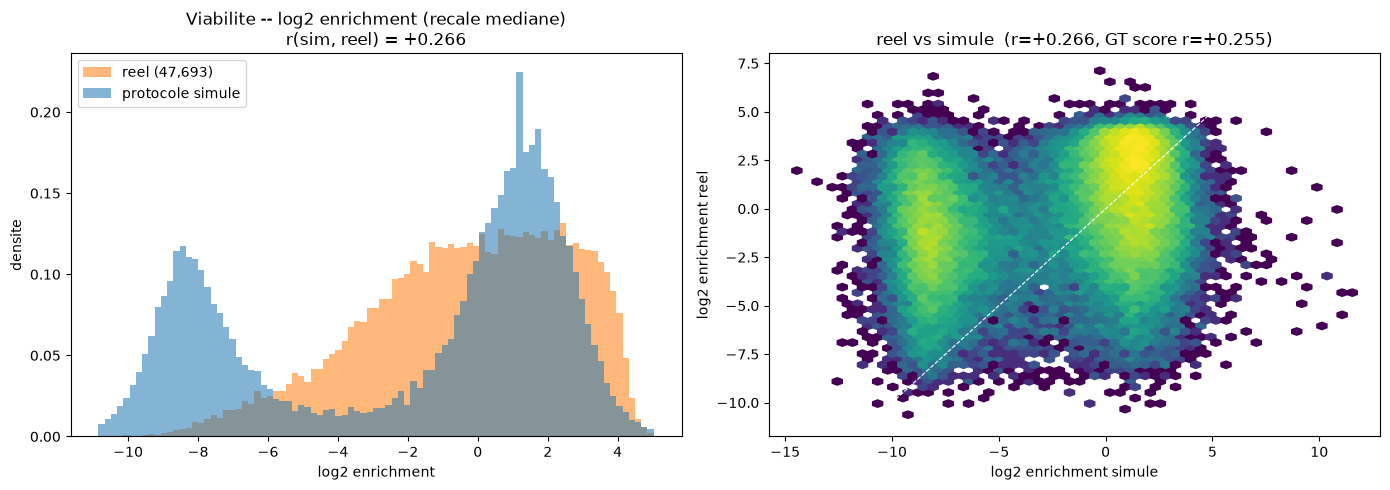

In [6]:
def center(x):
    x = np.asarray(x, np.float64)
    return x - np.median(x[np.isfinite(x)])

sim_viab = sims[0]["sim_viab"]
rv, sv = center(y_viab), center(sim_viab)
mfin = np.isfinite(rv) & np.isfinite(sv)
r_viab_sim = pearson(rv[mfin], sv[mfin])
print(f"r(sim_viab, reel viab) = {r_viab_sim:+.3f}   (n={mfin.sum():,}, GT score r={r_viab_gt:+.3f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
lo, hi = np.percentile(np.concatenate([rv[mfin], sv[mfin]]), [0.2, 99.8])
bins = np.linspace(lo, hi, 90)
axes[0].hist(rv[mfin], bins=bins, density=True, alpha=0.55, color="tab:orange", label=f"reel ({mfin.sum():,})")
axes[0].hist(sv[mfin], bins=bins, density=True, alpha=0.55, color="tab:blue",   label="protocole simule")
axes[0].set(title=f"Viabilite -- log2 enrichment (recale mediane)\nr(sim, reel) = {r_viab_sim:+.3f}",
            xlabel="log2 enrichment", ylabel="densite"); axes[0].legend()

axes[1].hexbin(sv[mfin], rv[mfin], gridsize=55, bins="log", cmap="viridis", mincnt=1)
d = [max(sv[mfin].min(), lo), min(sv[mfin].max(), hi)]
axes[1].plot(d, d, "w--", lw=0.8)
axes[1].set(title=f"reel vs simule  (r={r_viab_sim:+.3f}, GT score r={r_viab_gt:+.3f})",
            xlabel="log2 enrichment simule", ylabel="log2 enrichment reel")
plt.tight_layout(); plt.show()

### 6. Selectivite -- reel (org2, org3) vs protocole (3 replicats simules)

`log2_enrichissement_organoide_{2,3}_adn_sur_virus` reel vs `log2((lambda3p+eps)/(lambda2p+eps))`
simule (3 replicats, cles differentes). Tout recale mediane.

r(sim_sel rep0, reel org2) = +0.240   (n=50,000, GT score r=+0.555)
r(sim_sel rep0, reel org3) = +0.207   (n=50,000, GT score r=+0.481)


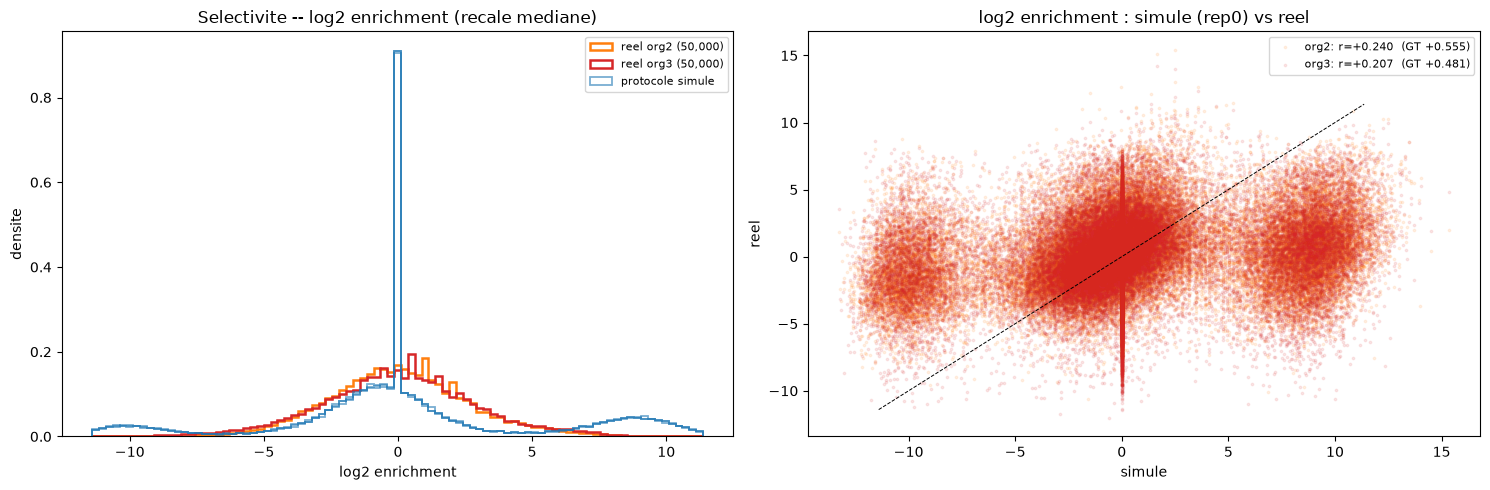

accord replicat-replicat :
  reel   org2 vs org3  : +0.694
  simule rep0 vs rep1  : +0.221
  simule rep0 vs rep2  : +0.220


In [7]:
sims_sel_c = [center(s["sim_sel"]) for s in sims]
real_sel_c = {i: center(y_sel[i]) for i in (2, 3)}

allv = np.concatenate([real_sel_c[2], real_sel_c[3]] + [ss[np.isfinite(ss)] for ss in sims_sel_c])
lo, hi = np.percentile(allv, [0.5, 99.5])
bins = np.linspace(lo, hi, 90)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(real_sel_c[2], bins=bins, density=True, histtype="step", lw=1.8,
             color="tab:orange", label=f"reel org2 ({d0:,})")
axes[0].hist(real_sel_c[3], bins=bins, density=True, histtype="step", lw=1.8,
             color="tab:red", label=f"reel org3 ({d0:,})")
for k, ss in enumerate(sims_sel_c):
    axes[0].hist(ss[np.isfinite(ss)], bins=bins, density=True, histtype="step", lw=1.3,
                 color="tab:blue", alpha=0.6, label="protocole simule" if k == 0 else None)
axes[0].set(title="Selectivite -- log2 enrichment (recale mediane)",
            xlabel="log2 enrichment", ylabel="densite"); axes[0].legend(fontsize=8)

s0 = sims_sel_c[0]
for i, col in zip((2, 3), ("tab:orange", "tab:red")):
    m = np.isfinite(s0)
    r = pearson(real_sel_c[i][m], s0[m])
    print(f"r(sim_sel rep0, reel org{i}) = {r:+.3f}   (n={m.sum():,}, GT score r={r_sel_gt[i]:+.3f})")
    axes[1].scatter(s0[m], real_sel_c[i][m], s=3, alpha=0.1, color=col,
                    label=f"org{i}: r={r:+.3f}  (GT {r_sel_gt[i]:+.3f})")
axes[1].plot([lo, hi], [lo, hi], "k--", lw=0.7)
axes[1].set(title="log2 enrichment : simule (rep0) vs reel", xlabel="simule", ylabel="reel")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

def r_between(a, b):
    a, b = np.asarray(a), np.asarray(b)
    m = np.isfinite(a) & np.isfinite(b)
    return pearson(a[m], b[m])

print("accord replicat-replicat :")
print(f"  reel   org2 vs org3  : {r_between(real_sel_c[2], real_sel_c[3]):+.3f}")
print(f"  simule rep0 vs rep1  : {r_between(sims_sel_c[0], sims_sel_c[1]):+.3f}")
print(f"  simule rep0 vs rep2  : {r_between(sims_sel_c[0], sims_sel_c[2]):+.3f}")

### 7. Recovery des meilleurs variants

Pour chaque cible (viab, sel org2, sel org3) : quelle fraction du vrai top-k% (classe par la
mesure reelle) est retrouvee dans le top-k% classe par (a) le score GT deterministe, (b) le log
enrichment simule. Ligne pointillee = tirage au hasard.

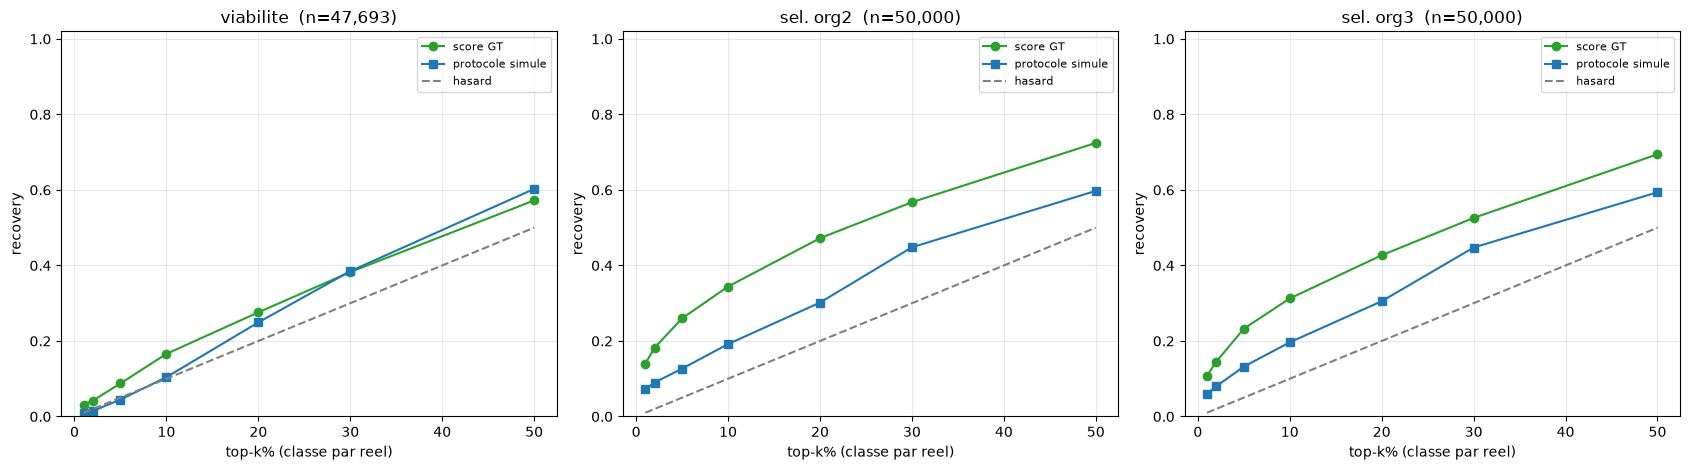

recovery_GT                     recovery_sim                    
cible    sel. org2 sel. org3 viabilite    sel. org2 sel. org3 viabilite
top_k%                                                                 
1            0.140     0.108     0.032        0.072     0.060     0.011
2            0.182     0.145     0.042        0.090     0.080     0.015
5            0.260     0.232     0.088        0.127     0.132     0.045
10           0.344     0.313     0.166        0.192     0.196     0.104
20           0.472     0.427     0.276        0.302     0.305     0.249
30           0.567     0.526     0.383        0.448     0.447     0.385
50           0.725     0.694     0.572        0.598     0.594     0.603

In [8]:
PCTS = [1, 2, 5, 10, 20, 30, 50]

def recovery_curve(y_real, ranker, mask=None):
    if mask is None:
        mask = np.ones_like(y_real, dtype=bool)
    yr, rk = y_real[mask], ranker[mask]
    ok = np.isfinite(yr) & np.isfinite(rk)
    yr, rk = yr[ok], rk[ok]
    return [precision_at_k(yr, rk, k_frac=p / 100) for p in PCTS], len(yr)

targets = [
    ("viabilite", y_viab,    viab_score_GT, sim_viab,           np.isfinite(y_viab)),
    ("sel. org2", y_sel[2],  sel_score_GT,  sims[0]["sim_sel"], None),
    ("sel. org3", y_sel[3],  sel_score_GT,  sims[0]["sim_sel"], None),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
rows = []
for ax, (name, y_real, gt, simlog, mask) in zip(axes, targets):
    rec_gt,  n = recovery_curve(y_real, gt, mask)
    rec_sim, _ = recovery_curve(y_real, simlog, mask)
    ax.plot(PCTS, rec_gt,  "o-", color="tab:green", label="score GT")
    ax.plot(PCTS, rec_sim, "s-", color="tab:blue",  label="protocole simule")
    ax.plot(PCTS, [p / 100 for p in PCTS], "--", color="grey", label="hasard")
    ax.set(title=f"{name}  (n={n:,})", xlabel="top-k% (classe par reel)",
           ylabel="recovery", ylim=(0, 1.02)); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    for p, g, s in zip(PCTS, rec_gt, rec_sim):
        rows.append({"cible": name, "top_k%": p, "recovery_GT": round(g, 3), "recovery_sim": round(s, 3)})
plt.tight_layout(); plt.show()
pd.DataFrame(rows).pivot(index="top_k%", columns="cible", values=["recovery_GT", "recovery_sim"])

### 8. Population a travers le pipeline simule

In [9]:
p0 = sims[0]["p"]
lambdas_np = {
    "lambda0 (librairie = avg org2/org3)": np.asarray(p0.lambda0),
    "lambda0p (NGS plasmide simule)":      sims[0]["l0p"],
    "lambda2 (capsides)":                  np.asarray(p0.lambda2),
    "lambda2p (NGS virus simule)":         sims[0]["l2p"],
    "lambda3 (post-selectivite)":          np.asarray(p0.lambda3),
    "lambda3p (NGS organoide simule)":     sims[0]["l3p"],
}
summary = pd.DataFrame({
    "total": [a.sum() for a in lambdas_np.values()],
    "n_variants (>=1)": [int((a >= 1).sum()) for a in lambdas_np.values()],
    "fraction_d0": [float((a >= 1).mean()) for a in lambdas_np.values()],
}, index=list(lambdas_np))
display(summary)
display(number_of_seq_threshold(lambdas_np, thresholds=[1, 10, 100, 1000]))

,total,n_variants (>=1),fraction_d0
lambda0 (librairie = avg org2/org3),9.877002e+11,50000,1.00000
lambda0p (NGS plasmide simule),9.999640e+07,49119,0.98238
lambda2 (capsides),2.752945e+10,47154,0.94308
lambda2p (NGS virus simule),9.999800e+07,30955,0.61910
lambda3 (post-selectivite),9.567183e+10,47154,0.94308
lambda3p (NGS organoide simule),9.999742e+07,35676,0.71352


,1.0,10.0,100.0,1000.0
lambda,,,,
lambda0 (librairie = avg org2/org3),50000,50000,50000,50000
lambda0p (NGS plasmide simule),49119,48287,44163,16311
lambda2 (capsides),47154,47154,47154,47124
lambda2p (NGS virus simule),30955,30835,29303,15290
lambda3 (post-selectivite),47154,47154,47154,47120
lambda3p (NGS organoide simule),35676,35233,30387,11557


### 9. Notes

- Parametres protocole (`mu`/`T`/`noise`/`D`) **non recalibres pour ce run** -- repris tels quels
  de `AAV5_SEL_fitting_protocol.ipynb`, comme demande ("parametres classiques, pas de sweep").
- Poids de selectivite = fit mutualise org2+org3 a `compte>=20`
  (`AAV5_SEL_potts_readout_depth.ipynb`) -- pas re-fittes sur ce sous-echantillon precis
  org2∩org3 (146 589 lignes, critere `>0` plutot que `>=20`). Le plafond reel sur ce sous-ensemble
  est `r(org2, org3)` affiche en section 6.
- `plasmid_count = avg(compte_organoide_2_adn, compte_organoide_3_adn)` sert de librairie
  initiale a la place du vrai `compte_plasmide` -- un choix delibere de ce run, pas une
  approximation du plasmide reel.